# 비트코인 수익률 변동성 예측_LSTM+GARCH

# 5B

X_train: (6534, 42, 2) Y_train: (6534, 1)
X_test: (554, 42, 2) Y_test: (554, 1)
Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - loss: 9.8022e-05 - root_mean_squared_error: 0.0098 - val_loss: 1.0654e-05 - val_root_mean_squared_error: 0.0033
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - loss: 2.7379e-05 - root_mean_squared_error: 0.0052 - val_loss: 8.7274e-06 - val_root_mean_squared_error: 0.0030
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - loss: 3.3098e-05 - root_mean_squared_error: 0.0057 - val_loss: 6.1129e-06 - val_root_mean_squared_error: 0.0025
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - loss: 2.0271e-05 - root_mean_squared_error: 0.0045 - val_loss: 6.7510e-06 - val_root_mean_squared_error: 0.0026
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - loss: 9.7839e-06 - root_mean_squared_error: 0.0031 - val_loss: 3.4682e-06 - val_root_mean_squared_error: 0.0019
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - loss: 1.1456e-05 - root_mean_squared_error

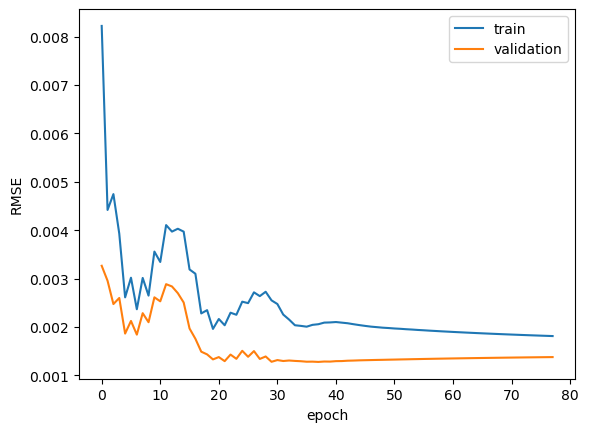

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step

RMSE: 0.00172

HMAE: 1.17552
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step


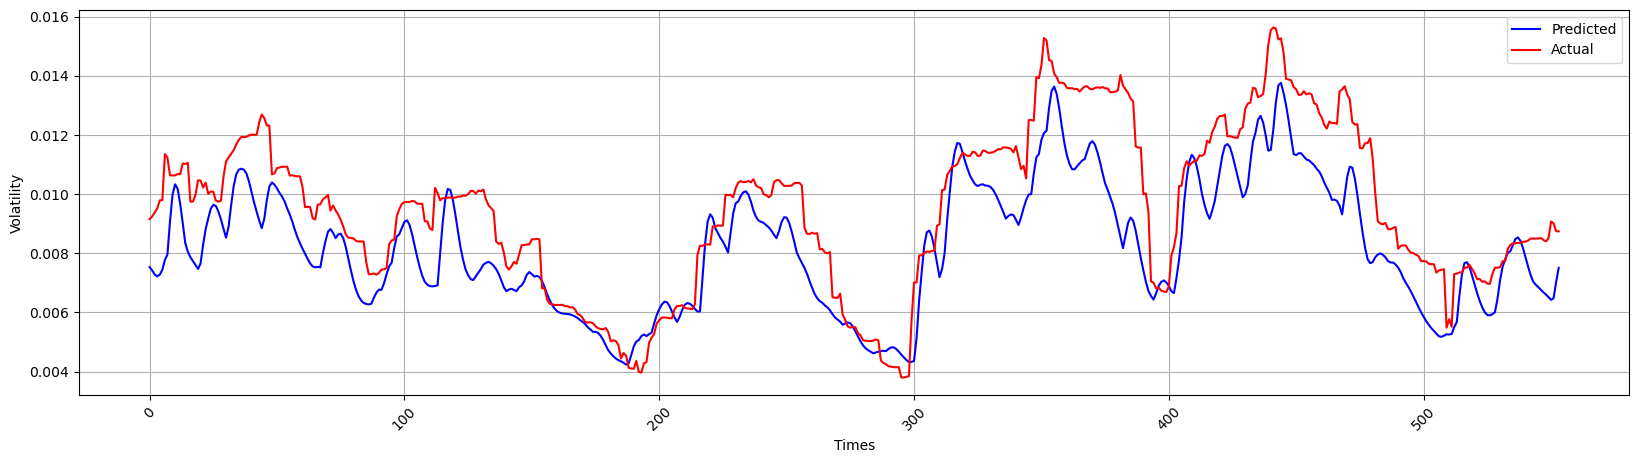

In [1]:
# 6/13 수정중
# HMAE 코드 수정
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import Loss
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import math
import random

# 데이터셋 준비
df = pd.read_csv('finally_para_py_GARCH1_2_BTC_CBOE_VIX_KOSPI200_USDKRW.csv')

# 'index' 열의 datetime 변환 및 인덱스 설정
df['index'] = pd.to_datetime(df['datetime'])
df.set_index(df['index'], inplace=True)

# # 경제지표 모두 추가
# X_garch = df[['garch_vol', 'KOSPI200_vol', 'CBOE_VIX_vol', 'USD_KRW_vol']].values 

# # 경제지표 다 뺌
# X_garch = df[['garch_vol', 'predicted_volatility']].values 

# #USD_KRW_vol만 추가
# X_garch = df[['garch_vol', 'predicted_volatility','USD_KRW_vol']].values 

# #'CBOE_VIX_vol'만 추가
# X_garch = df[['garch_vol', 'predicted_volatility','CBOE_VIX_vol']].values 

#KOSPI200_vol만 추가
X_garch = df[['garch_vol', 'KOSPI200_vol']].values

# #USD + CBOE 조합
# X_garch = df[['garch_vol', 'predicted_volatility','USD_KRW_vol','CBOE_VIX_vol']].values 

# #USD + KOSPI 조합
# X_garch = df[['garch_vol', 'predicted_volatility','USD_KRW_vol','KOSPI200_vol']].values 

# #CEOB + KOSPI 조합
# X_garch = df[['garch_vol', 'predicted_volatility','CBOE_VIX_vol','KOSPI200_vol']].values 



y = df['historical_volatility'].values

def dataset_split(x_set, y_set):
    train_end = df.index.get_loc('2022-12-31 21:00:00')
    valid_end = df.index.get_loc('2023-12-31 21:00:00')
    train_x = x_set[:train_end + 1]
    train_y = y_set[:train_end + 1]
    valid_x = x_set[train_end + 1:valid_end + 1]
    valid_y = y_set[train_end + 1:valid_end + 1]
    test_x = x_set[valid_end + 1:]
    test_y = y_set[valid_end + 1:]
    return train_x, train_y, valid_x, valid_y, test_x, test_y

train_X_garch, train_y_garch, valid_X_garch, valid_y_garch, test_X_garch, test_y_garch = dataset_split(X_garch, y)

# 스케일러 초기화
scaler_x = MinMaxScaler(feature_range=(0, 1))
train_X_scaled = scaler_x.fit_transform(train_X_garch)
valid_X_scaled = scaler_x.transform(valid_X_garch)
test_X_scaled = scaler_x.transform(test_X_garch)

sequence = 42
X_train, Y_train = [], []
for index in range(len(train_X_scaled) - sequence):
    X_train.append(np.array(train_X_scaled[index: index + sequence]))
    Y_train.append(np.ravel(train_y_garch[index + sequence:index + sequence + 1]))
X_train, Y_train = np.array(X_train), np.array(Y_train)

X_valid, Y_valid = [], []
for index in range(len(valid_X_scaled) - sequence):
    X_valid.append(np.array(valid_X_scaled[index: index + sequence]))
    Y_valid.append(np.ravel(valid_y_garch[index + sequence:index + sequence + 1]))
X_valid, Y_valid = np.array(X_valid), np.array(Y_valid)

X_test, Y_test = [], []
for index in range(len(test_X_scaled) - sequence):
    X_test.append(np.array(test_X_scaled[index: index + sequence]))
    Y_test.append(np.ravel(test_y_garch[index + sequence:index + sequence + 1]))
X_test, Y_test = np.array(X_test), np.array(Y_test)

train_y_garch = Y_train
valid_y_garch = Y_valid
test_y_garch = Y_test

train_X_garch = X_train.reshape(X_train.shape[0], sequence, -1)
valid_X_garch = X_valid.reshape(X_valid.shape[0], sequence, -1)
test_X_garch = X_test.reshape(X_test.shape[0], sequence, -1)

print('X_train:', train_X_garch.shape, 'Y_train:', train_y_garch.shape)
print('X_test:', test_X_garch.shape, 'Y_test:', test_y_garch.shape)


# HMAE 계산 함수
class HMAELoss(Loss):
    def __init__(self, name='hmae_loss'):
        super(HMAELoss, self).__init__(name=name)

    def call(self, y_true, y_pred):
        error = tf.abs(y_true - y_pred)
        variance = tf.math.reduce_variance(tf.cast(y_true - y_pred, tf.float32), axis=-1)
        hmae = tf.reduce_mean(error / tf.sqrt(variance + tf.keras.backend.epsilon()))
        return hmae

stop_early = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=40, verbose=1)

def build_model():
    inputLSTM_GARCH_EGARCH = tf.keras.layers.Input(shape=(train_X_garch.shape[1], train_X_garch.shape[2]))
    y = tf.keras.layers.LSTM(units=500, return_sequences=True)(inputLSTM_GARCH_EGARCH)
    y = tf.keras.layers.LSTM(units=500)(y)
    y = tf.keras.layers.Dense(1)(y)

    model = tf.keras.Model(inputs=inputLSTM_GARCH_EGARCH, outputs=y)

    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss=tf.keras.losses.MeanSquaredError(),
                  metrics=[tf.keras.metrics.RootMeanSquaredError()])
    return model


SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

model = build_model()
history = model.fit(train_X_garch, train_y_garch,
                    epochs=100,
                    validation_data=(valid_X_garch, valid_y_garch),
                    batch_size=512,
                    callbacks=[stop_early],
                    shuffle=False)


def model_RMSE_plot(hist_model, model_name):
    plt.plot(hist_model.history['root_mean_squared_error'])
    plt.plot(hist_model.history['val_root_mean_squared_error'])
    #plt.title('{} train vs validation RMSE'.format(model_name))
    plt.ylabel('RMSE')
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'], loc='upper right')
    plt.show()

def printing_out_results_of_a_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_test = y_test.flatten()
    y_pred = y_pred.flatten()

    rmse = math.sqrt(mean_squared_error(y_test, y_pred))
    print(f"\nRMSE: {rmse:.5f}")

    hmae_loss = HMAELoss()
    hmae_value = hmae_loss(tf.convert_to_tensor(y_test, dtype=tf.float32), tf.convert_to_tensor(y_pred, dtype=tf.float32))
    print(f"\nHMAE: {hmae_value.numpy():.5f}")

model_RMSE_plot(history, "LSTM_GARCH_vol")
printing_out_results_of_a_model(model, test_X_garch, test_y_garch)

def result_to_excel(model, test_X_garch, test_y_garch):
    result_df = pd.DataFrame(columns=['Prediction_y', 'Actual_y'])
    for ind, prediction in enumerate(model.predict(test_X_garch)):
        result_df.loc[ind] = [prediction[0], test_y_garch[ind]]
    result_df.to_excel('LSTM_GARCH_5B.xlsx', index=False)
    return result_df

result_df = result_to_excel(model, test_X_garch, test_y_garch)
plt.figure(figsize=(20, 5))
plt.plot(result_df['Prediction_y'], linestyle='-', color='blue', label='Predicted')
plt.plot(result_df['Actual_y'], linestyle='-', color='red', label='Actual')
plt.xlabel('Times')
plt.ylabel('Volatility')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

# 6B

X_train: (6534, 42, 3) Y_train: (6534, 1)
X_test: (554, 42, 3) Y_test: (554, 1)
Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - loss: 2.6649e-04 - root_mean_squared_error: 0.0160 - val_loss: 4.8893e-05 - val_root_mean_squared_error: 0.0070
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - loss: 1.6522e-04 - root_mean_squared_error: 0.0124 - val_loss: 5.2540e-05 - val_root_mean_squared_error: 0.0072
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - loss: 1.0105e-04 - root_mean_squared_error: 0.0098 - val_loss: 1.1300e-04 - val_root_mean_squared_error: 0.0106
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - loss: 1.5840e-04 - root_mean_squared_error: 0.0124 - val_loss: 1.8155e-05 - val_root_mean_squared_error: 0.0043
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - loss: 2.6545e-05 - root_mean_squared_error: 0.0051 - val_loss: 1.0829e-05 - val_root_mean_squared_error: 0.0033
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - loss: 3.0182e-05 - root_mean_squared_error

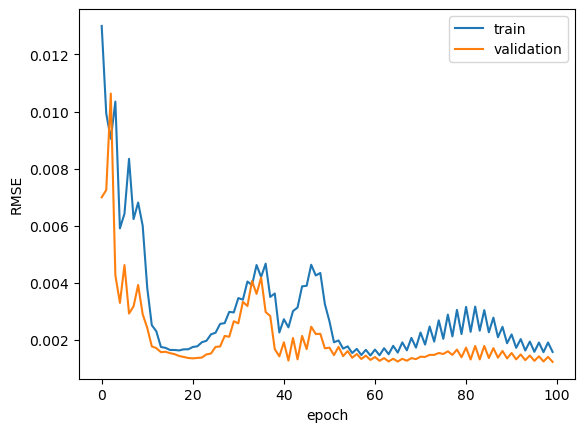

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step

RMSE: 0.00146

HMAE: 0.95434
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step


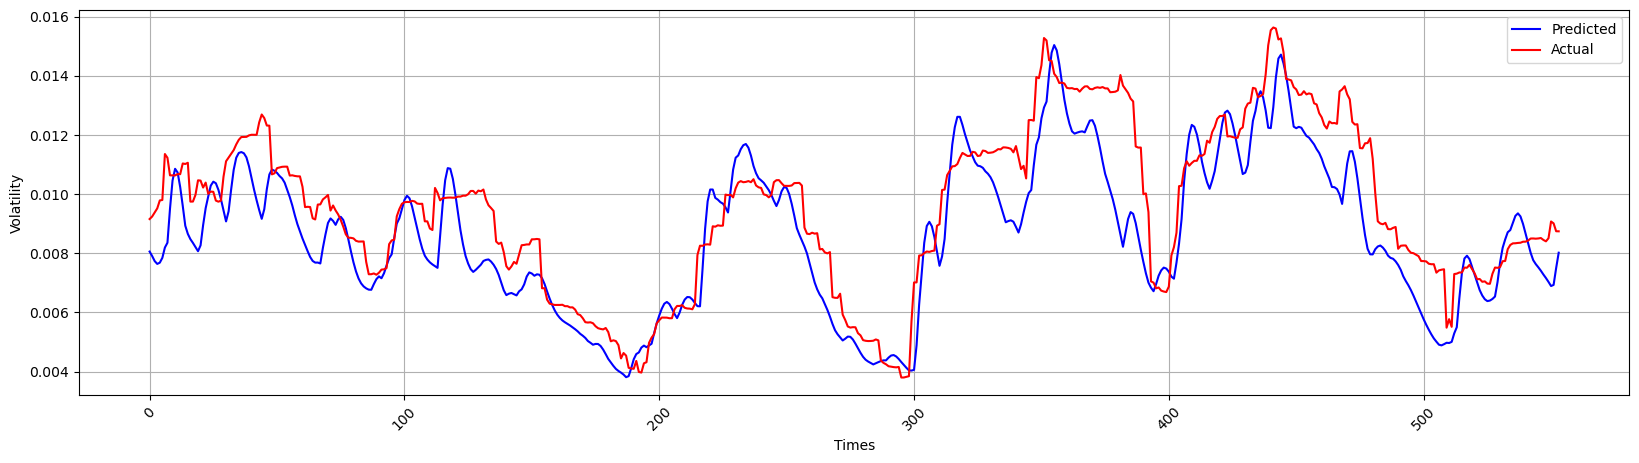

In [2]:
# 6/13 수정중
# HMAE 코드 수정
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import Loss
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import math
import random

# 데이터셋 준비
df = pd.read_csv('finally_para_py_GARCH1_2_BTC_CBOE_VIX_KOSPI200_USDKRW.csv')

# 'index' 열의 datetime 변환 및 인덱스 설정
df['index'] = pd.to_datetime(df['datetime'])
df.set_index(df['index'], inplace=True)

# # 경제지표 모두 추가
# X_garch = df[['garch_vol', 'KOSPI200_vol', 'CBOE_VIX_vol', 'USD_KRW_vol']].values 

# # 경제지표 다 뺌
# X_garch = df[['garch_vol']].values 

# #USD_KRW_vol만 추가
# X_garch = df[['garch_vol', 'predicted_volatility','USD_KRW_vol']].values 

# #'CBOE_VIX_vol'만 추가
# X_garch = df[['garch_vol', 'predicted_volatility','CBOE_VIX_vol']].values 

# #KOSPI200_vol만 추가
# X_garch = df[['garch_vol', 'predicted_volatility','KOSPI200_vol']].values

#USD + CBOE 조합
X_garch = df[['garch_vol', 'USD_KRW_vol', 'CBOE_VIX_vol']].values 

# #USD + KOSPI 조합
# X_garch = df[['garch_vol', 'predicted_volatility','USD_KRW_vol','KOSPI200_vol']].values 

# #CEOB + KOSPI 조합
# X_garch = df[['garch_vol', 'predicted_volatility','CBOE_VIX_vol','KOSPI200_vol']].values 



y = df['historical_volatility'].values

def dataset_split(x_set, y_set):
    train_end = df.index.get_loc('2022-12-31 21:00:00')
    valid_end = df.index.get_loc('2023-12-31 21:00:00')
    train_x = x_set[:train_end + 1]
    train_y = y_set[:train_end + 1]
    valid_x = x_set[train_end + 1:valid_end + 1]
    valid_y = y_set[train_end + 1:valid_end + 1]
    test_x = x_set[valid_end + 1:]
    test_y = y_set[valid_end + 1:]
    return train_x, train_y, valid_x, valid_y, test_x, test_y

train_X_garch, train_y_garch, valid_X_garch, valid_y_garch, test_X_garch, test_y_garch = dataset_split(X_garch, y)

# 스케일러 초기화
scaler_x = MinMaxScaler(feature_range=(0, 1))
train_X_scaled = scaler_x.fit_transform(train_X_garch)
valid_X_scaled = scaler_x.transform(valid_X_garch)
test_X_scaled = scaler_x.transform(test_X_garch)

sequence = 42
X_train, Y_train = [], []
for index in range(len(train_X_scaled) - sequence):
    X_train.append(np.array(train_X_scaled[index: index + sequence]))
    Y_train.append(np.ravel(train_y_garch[index + sequence:index + sequence + 1]))
X_train, Y_train = np.array(X_train), np.array(Y_train)

X_valid, Y_valid = [], []
for index in range(len(valid_X_scaled) - sequence):
    X_valid.append(np.array(valid_X_scaled[index: index + sequence]))
    Y_valid.append(np.ravel(valid_y_garch[index + sequence:index + sequence + 1]))
X_valid, Y_valid = np.array(X_valid), np.array(Y_valid)

X_test, Y_test = [], []
for index in range(len(test_X_scaled) - sequence):
    X_test.append(np.array(test_X_scaled[index: index + sequence]))
    Y_test.append(np.ravel(test_y_garch[index + sequence:index + sequence + 1]))
X_test, Y_test = np.array(X_test), np.array(Y_test)

train_y_garch = Y_train
valid_y_garch = Y_valid
test_y_garch = Y_test

train_X_garch = X_train.reshape(X_train.shape[0], sequence, -1)
valid_X_garch = X_valid.reshape(X_valid.shape[0], sequence, -1)
test_X_garch = X_test.reshape(X_test.shape[0], sequence, -1)

print('X_train:', train_X_garch.shape, 'Y_train:', train_y_garch.shape)
print('X_test:', test_X_garch.shape, 'Y_test:', test_y_garch.shape)


# HMAE 계산 함수
class HMAELoss(Loss):
    def __init__(self, name='hmae_loss'):
        super(HMAELoss, self).__init__(name=name)

    def call(self, y_true, y_pred):
        error = tf.abs(y_true - y_pred)
        variance = tf.math.reduce_variance(tf.cast(y_true - y_pred, tf.float32), axis=-1)
        hmae = tf.reduce_mean(error / tf.sqrt(variance + tf.keras.backend.epsilon()))
        return hmae

stop_early = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=40, verbose=1)

def build_model():
    inputLSTM_GARCH_EGARCH = tf.keras.layers.Input(shape=(train_X_garch.shape[1], train_X_garch.shape[2]))
    y = tf.keras.layers.LSTM(units=500, return_sequences=True)(inputLSTM_GARCH_EGARCH)
    y = tf.keras.layers.LSTM(units=500)(y)
    y = tf.keras.layers.Dense(1)(y)

    model = tf.keras.Model(inputs=inputLSTM_GARCH_EGARCH, outputs=y)

    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss=tf.keras.losses.MeanSquaredError(),
                  metrics=[tf.keras.metrics.RootMeanSquaredError()])
    return model


SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

model = build_model()
history = model.fit(train_X_garch, train_y_garch,
                    epochs=100,
                    validation_data=(valid_X_garch, valid_y_garch),
                    batch_size=512,
                    callbacks=[stop_early],
                    shuffle=False)


def model_RMSE_plot(hist_model, model_name):
    plt.plot(hist_model.history['root_mean_squared_error'])
    plt.plot(hist_model.history['val_root_mean_squared_error'])
    #plt.title('{} train vs validation RMSE'.format(model_name))
    plt.ylabel('RMSE')
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'], loc='upper right')
    plt.show()

def printing_out_results_of_a_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_test = y_test.flatten()
    y_pred = y_pred.flatten()

    rmse = math.sqrt(mean_squared_error(y_test, y_pred))
    print(f"\nRMSE: {rmse:.5f}")

    hmae_loss = HMAELoss()
    hmae_value = hmae_loss(tf.convert_to_tensor(y_test, dtype=tf.float32), tf.convert_to_tensor(y_pred, dtype=tf.float32))
    print(f"\nHMAE: {hmae_value.numpy():.5f}")

model_RMSE_plot(history, "LSTM_GARCH_vol")
printing_out_results_of_a_model(model, test_X_garch, test_y_garch)

def result_to_excel(model, test_X_garch, test_y_garch):
    result_df = pd.DataFrame(columns=['Prediction_y', 'Actual_y'])
    for ind, prediction in enumerate(model.predict(test_X_garch)):
        result_df.loc[ind] = [prediction[0], test_y_garch[ind]]
    result_df.to_excel('LSTM_GARCH_6B.xlsx', index=False)
    return result_df

result_df = result_to_excel(model, test_X_garch, test_y_garch)
plt.figure(figsize=(20, 5))
plt.plot(result_df['Prediction_y'], linestyle='-', color='blue', label='Predicted')
plt.plot(result_df['Actual_y'], linestyle='-', color='red', label='Actual')
plt.xlabel('Times')
plt.ylabel('Volatility')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

# 7B

In [ ]:
# 6/13 수정중
# HMAE 코드 수정
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import Loss
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import math
import random

# 데이터셋 준비
df = pd.read_csv('finally_para_py_GARCH1_2_BTC_CBOE_VIX_KOSPI200_USDKRW.csv')

# 'index' 열의 datetime 변환 및 인덱스 설정
df['index'] = pd.to_datetime(df['datetime'])
df.set_index(df['index'], inplace=True)

# # 경제지표 모두 추가
# X_garch = df[['garch_vol', 'KOSPI200_vol', 'CBOE_VIX_vol', 'USD_KRW_vol']].values 

# # 경제지표 다 뺌
# X_garch = df[['garch_vol']].values 

# #USD_KRW_vol만 추가
# X_garch = df[['garch_vol', 'predicted_volatility','USD_KRW_vol']].values 

# #'CBOE_VIX_vol'만 추가
# X_garch = df[['garch_vol', 'predicted_volatility','CBOE_VIX_vol']].values 

# #KOSPI200_vol만 추가
# X_garch = df[['garch_vol', 'predicted_volatility','KOSPI200_vol']].values

# #USD + CBOE 조합
# X_garch = df[['garch_vol', 'predicted_volatility','USD_KRW_vol','CBOE_VIX_vol']].values 

#USD + KOSPI 조합
X_garch = df[['garch_vol', 'USD_KRW_vol', 'KOSPI200_vol']].values 

# #CEOB + KOSPI 조합
# X_garch = df[['garch_vol', 'predicted_volatility','CBOE_VIX_vol','KOSPI200_vol']].values 



y = df['historical_volatility'].values

def dataset_split(x_set, y_set):
    train_end = df.index.get_loc('2022-12-31 21:00:00')
    valid_end = df.index.get_loc('2023-12-31 21:00:00')
    train_x = x_set[:train_end + 1]
    train_y = y_set[:train_end + 1]
    valid_x = x_set[train_end + 1:valid_end + 1]
    valid_y = y_set[train_end + 1:valid_end + 1]
    test_x = x_set[valid_end + 1:]
    test_y = y_set[valid_end + 1:]
    return train_x, train_y, valid_x, valid_y, test_x, test_y

train_X_garch, train_y_garch, valid_X_garch, valid_y_garch, test_X_garch, test_y_garch = dataset_split(X_garch, y)

# 스케일러 초기화
scaler_x = MinMaxScaler(feature_range=(0, 1))
train_X_scaled = scaler_x.fit_transform(train_X_garch)
valid_X_scaled = scaler_x.transform(valid_X_garch)
test_X_scaled = scaler_x.transform(test_X_garch)

sequence = 42
X_train, Y_train = [], []
for index in range(len(train_X_scaled) - sequence):
    X_train.append(np.array(train_X_scaled[index: index + sequence]))
    Y_train.append(np.ravel(train_y_garch[index + sequence:index + sequence + 1]))
X_train, Y_train = np.array(X_train), np.array(Y_train)

X_valid, Y_valid = [], []
for index in range(len(valid_X_scaled) - sequence):
    X_valid.append(np.array(valid_X_scaled[index: index + sequence]))
    Y_valid.append(np.ravel(valid_y_garch[index + sequence:index + sequence + 1]))
X_valid, Y_valid = np.array(X_valid), np.array(Y_valid)

X_test, Y_test = [], []
for index in range(len(test_X_scaled) - sequence):
    X_test.append(np.array(test_X_scaled[index: index + sequence]))
    Y_test.append(np.ravel(test_y_garch[index + sequence:index + sequence + 1]))
X_test, Y_test = np.array(X_test), np.array(Y_test)

train_y_garch = Y_train
valid_y_garch = Y_valid
test_y_garch = Y_test

train_X_garch = X_train.reshape(X_train.shape[0], sequence, -1)
valid_X_garch = X_valid.reshape(X_valid.shape[0], sequence, -1)
test_X_garch = X_test.reshape(X_test.shape[0], sequence, -1)

print('X_train:', train_X_garch.shape, 'Y_train:', train_y_garch.shape)
print('X_test:', test_X_garch.shape, 'Y_test:', test_y_garch.shape)


# HMAE 계산 함수
class HMAELoss(Loss):
    def __init__(self, name='hmae_loss'):
        super(HMAELoss, self).__init__(name=name)

    def call(self, y_true, y_pred):
        error = tf.abs(y_true - y_pred)
        variance = tf.math.reduce_variance(tf.cast(y_true - y_pred, tf.float32), axis=-1)
        hmae = tf.reduce_mean(error / tf.sqrt(variance + tf.keras.backend.epsilon()))
        return hmae

stop_early = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=40, verbose=1)

def build_model():
    inputLSTM_GARCH_EGARCH = tf.keras.layers.Input(shape=(train_X_garch.shape[1], train_X_garch.shape[2]))
    y = tf.keras.layers.LSTM(units=500, return_sequences=True)(inputLSTM_GARCH_EGARCH)
    y = tf.keras.layers.LSTM(units=500)(y)
    y = tf.keras.layers.Dense(1)(y)

    model = tf.keras.Model(inputs=inputLSTM_GARCH_EGARCH, outputs=y)

    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss=tf.keras.losses.MeanSquaredError(),
                  metrics=[tf.keras.metrics.RootMeanSquaredError()])
    return model


SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

model = build_model()
history = model.fit(train_X_garch, train_y_garch,
                    epochs=100,
                    validation_data=(valid_X_garch, valid_y_garch),
                    batch_size=512,
                    callbacks=[stop_early],
                    shuffle=False)


def model_RMSE_plot(hist_model, model_name):
    plt.plot(hist_model.history['root_mean_squared_error'])
    plt.plot(hist_model.history['val_root_mean_squared_error'])
    #plt.title('{} train vs validation RMSE'.format(model_name))
    plt.ylabel('RMSE')
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'], loc='upper right')
    plt.show()

def printing_out_results_of_a_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_test = y_test.flatten()
    y_pred = y_pred.flatten()

    rmse = math.sqrt(mean_squared_error(y_test, y_pred))
    print(f"\nRMSE: {rmse:.5f}")

    hmae_loss = HMAELoss()
    hmae_value = hmae_loss(tf.convert_to_tensor(y_test, dtype=tf.float32), tf.convert_to_tensor(y_pred, dtype=tf.float32))
    print(f"\nHMAE: {hmae_value.numpy():.5f}")

model_RMSE_plot(history, "LSTM_GARCH_vol")
printing_out_results_of_a_model(model, test_X_garch, test_y_garch)

def result_to_excel(model, test_X_garch, test_y_garch):
    result_df = pd.DataFrame(columns=['Prediction_y', 'Actual_y'])
    for ind, prediction in enumerate(model.predict(test_X_garch)):
        result_df.loc[ind] = [prediction[0], test_y_garch[ind]]
    result_df.to_excel('LSTM_GARCH_7B.xlsx', index=False)
    return result_df

result_df = result_to_excel(model, test_X_garch, test_y_garch)
plt.figure(figsize=(20, 5))
plt.plot(result_df['Prediction_y'], linestyle='-', color='blue', label='Predicted')
plt.plot(result_df['Actual_y'], linestyle='-', color='red', label='Actual')
plt.xlabel('Times')
plt.ylabel('Volatility')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

# 8B

In [ ]:
# 6/13 수정중
# HMAE 코드 수정
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import Loss
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import math
import random

# 데이터셋 준비
df = pd.read_csv('finally_para_py_GARCH1_2_BTC_CBOE_VIX_KOSPI200_USDKRW.csv')

# 'index' 열의 datetime 변환 및 인덱스 설정
df['index'] = pd.to_datetime(df['datetime'])
df.set_index(df['index'], inplace=True)

# # 경제지표 모두 추가
# X_garch = df[['garch_vol', 'KOSPI200_vol', 'CBOE_VIX_vol', 'USD_KRW_vol']].values 

# # 경제지표 다 뺌
# X_garch = df[['garch_vol']].values 

# #USD_KRW_vol만 추가
# X_garch = df[['garch_vol', 'predicted_volatility','USD_KRW_vol']].values 

# #'CBOE_VIX_vol'만 추가
# X_garch = df[['garch_vol', 'predicted_volatility','CBOE_VIX_vol']].values 

# #KOSPI200_vol만 추가
# X_garch = df[['garch_vol', 'predicted_volatility','KOSPI200_vol']].values

# #USD + CBOE 조합
# X_garch = df[['garch_vol', 'predicted_volatility','USD_KRW_vol','CBOE_VIX_vol']].values 

# #USD + KOSPI 조합
# X_garch = df[['garch_vol', 'USD_KRW_vol', 'KOSPI200_vol']].values 

#CEOB + KOSPI 조합
X_garch = df[['garch_vol', 'CBOE_VIX_vol', 'KOSPI200_vol']].values 



y = df['historical_volatility'].values

def dataset_split(x_set, y_set):
    train_end = df.index.get_loc('2022-12-31 21:00:00')
    valid_end = df.index.get_loc('2023-12-31 21:00:00')
    train_x = x_set[:train_end + 1]
    train_y = y_set[:train_end + 1]
    valid_x = x_set[train_end + 1:valid_end + 1]
    valid_y = y_set[train_end + 1:valid_end + 1]
    test_x = x_set[valid_end + 1:]
    test_y = y_set[valid_end + 1:]
    return train_x, train_y, valid_x, valid_y, test_x, test_y

train_X_garch, train_y_garch, valid_X_garch, valid_y_garch, test_X_garch, test_y_garch = dataset_split(X_garch, y)

# 스케일러 초기화
scaler_x = MinMaxScaler(feature_range=(0, 1))
train_X_scaled = scaler_x.fit_transform(train_X_garch)
valid_X_scaled = scaler_x.transform(valid_X_garch)
test_X_scaled = scaler_x.transform(test_X_garch)

sequence = 42
X_train, Y_train = [], []
for index in range(len(train_X_scaled) - sequence):
    X_train.append(np.array(train_X_scaled[index: index + sequence]))
    Y_train.append(np.ravel(train_y_garch[index + sequence:index + sequence + 1]))
X_train, Y_train = np.array(X_train), np.array(Y_train)

X_valid, Y_valid = [], []
for index in range(len(valid_X_scaled) - sequence):
    X_valid.append(np.array(valid_X_scaled[index: index + sequence]))
    Y_valid.append(np.ravel(valid_y_garch[index + sequence:index + sequence + 1]))
X_valid, Y_valid = np.array(X_valid), np.array(Y_valid)

X_test, Y_test = [], []
for index in range(len(test_X_scaled) - sequence):
    X_test.append(np.array(test_X_scaled[index: index + sequence]))
    Y_test.append(np.ravel(test_y_garch[index + sequence:index + sequence + 1]))
X_test, Y_test = np.array(X_test), np.array(Y_test)

train_y_garch = Y_train
valid_y_garch = Y_valid
test_y_garch = Y_test

train_X_garch = X_train.reshape(X_train.shape[0], sequence, -1)
valid_X_garch = X_valid.reshape(X_valid.shape[0], sequence, -1)
test_X_garch = X_test.reshape(X_test.shape[0], sequence, -1)

print('X_train:', train_X_garch.shape, 'Y_train:', train_y_garch.shape)
print('X_test:', test_X_garch.shape, 'Y_test:', test_y_garch.shape)


# HMAE 계산 함수
class HMAELoss(Loss):
    def __init__(self, name='hmae_loss'):
        super(HMAELoss, self).__init__(name=name)

    def call(self, y_true, y_pred):
        error = tf.abs(y_true - y_pred)
        variance = tf.math.reduce_variance(tf.cast(y_true - y_pred, tf.float32), axis=-1)
        hmae = tf.reduce_mean(error / tf.sqrt(variance + tf.keras.backend.epsilon()))
        return hmae

stop_early = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=40, verbose=1)

def build_model():
    inputLSTM_GARCH_EGARCH = tf.keras.layers.Input(shape=(train_X_garch.shape[1], train_X_garch.shape[2]))
    y = tf.keras.layers.LSTM(units=500, return_sequences=True)(inputLSTM_GARCH_EGARCH)
    y = tf.keras.layers.LSTM(units=500)(y)
    y = tf.keras.layers.Dense(1)(y)

    model = tf.keras.Model(inputs=inputLSTM_GARCH_EGARCH, outputs=y)

    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss=tf.keras.losses.MeanSquaredError(),
                  metrics=[tf.keras.metrics.RootMeanSquaredError()])
    return model


SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

model = build_model()
history = model.fit(train_X_garch, train_y_garch,
                    epochs=100,
                    validation_data=(valid_X_garch, valid_y_garch),
                    batch_size=512,
                    callbacks=[stop_early],
                    shuffle=False)


def model_RMSE_plot(hist_model, model_name):
    plt.plot(hist_model.history['root_mean_squared_error'])
    plt.plot(hist_model.history['val_root_mean_squared_error'])
    #plt.title('{} train vs validation RMSE'.format(model_name))
    plt.ylabel('RMSE')
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'], loc='upper right')
    plt.show()

def printing_out_results_of_a_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_test = y_test.flatten()
    y_pred = y_pred.flatten()

    rmse = math.sqrt(mean_squared_error(y_test, y_pred))
    print(f"\nRMSE: {rmse:.5f}")

    hmae_loss = HMAELoss()
    hmae_value = hmae_loss(tf.convert_to_tensor(y_test, dtype=tf.float32), tf.convert_to_tensor(y_pred, dtype=tf.float32))
    print(f"\nHMAE: {hmae_value.numpy():.5f}")

model_RMSE_plot(history, "LSTM_GARCH_vol")
printing_out_results_of_a_model(model, test_X_garch, test_y_garch)

def result_to_excel(model, test_X_garch, test_y_garch):
    result_df = pd.DataFrame(columns=['Prediction_y', 'Actual_y'])
    for ind, prediction in enumerate(model.predict(test_X_garch)):
        result_df.loc[ind] = [prediction[0], test_y_garch[ind]]
    result_df.to_excel('LSTM_GARCH_8B.xlsx', index=False)
    return result_df

result_df = result_to_excel(model, test_X_garch, test_y_garch)
plt.figure(figsize=(20, 5))
plt.plot(result_df['Prediction_y'], linestyle='-', color='blue', label='Predicted')
plt.plot(result_df['Actual_y'], linestyle='-', color='red', label='Actual')
plt.xlabel('Times')
plt.ylabel('Volatility')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()